# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Activity Notebook: The Pre-Publish Ethics Review

### Scenario

You're a junior analyst at **Northwind Retail Insights**. A colleague drafted a set of
charts for tomorrow's regional performance report, and your manager asked you to review
them before they go out. She's blunt about what she wants checked:

1. *"I can't tell what I'm supposed to look at first on any of these charts. There's no
   hierarchy."*
2. *"One of these charts will get someone using a grayscale office printer completely
   lost. Fix that before it ships."*
3. *"I saw a headline chart that made a tiny year-over-year change look like a crisis.
   Check the axis."*
4. *"Someone wrote 'this PROVES our new strategy is working' under a chart. That's not
   what a data label is for."*

You'll work through the same review a real analyst would: fix a hierarchy problem, make
a chart accessible, catch a scale exaggeration, and rewrite an overreaching annotation.

Cells marked **`# TODO`** are for you to complete. Markdown cells marked **Reflection**
are for you to answer in your own words.

## Part 0 — Setup (given)

Run this cell as-is. It loads the real sales data you'll be working with.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

np.random.seed(0)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

sales = pd.read_csv("superstore.csv", encoding="latin-1")
sales["Order Date"] = pd.to_datetime(sales["Order Date"])
sales["Year"] = sales["Order Date"].dt.year

print(f"Loaded {len(sales):,} orders, {sales.Year.min()}-{sales.Year.max()}.")
sales[["Order Date", "Region", "Product Category", "Sales", "Profit"]].head()

Loaded 8,399 orders, 2009-2012.


,Order Date,Region,Product Category,Sales,Profit
0,2010-10-13,Nunavut,Office Supplies,261.5400,-213.25
1,2012-10-01,Nunavut,Office Supplies,10123.0200,457.81
2,2012-10-01,Nunavut,Office Supplies,244.5700,46.71
3,2011-07-10,Nunavut,Technology,4965.7595,1198.97
4,2010-08-28,Nunavut,Office Supplies,394.2700,30.94


## Task 1 — Fix the Missing Hierarchy (Complaint #1)

**Real-world usage:** The manager can't tell what to look at first on the current
chart.

**Why this technique:** Visual hierarchy (size + weight + color) creates an
unmistakable primary -> secondary -> tertiary reading order without needing
instructions.

**TODO:** Build a figure with 3 text elements, using ONLY `fontsize`, `fontweight`, and
`color` to create hierarchy:
1. **Primary:** the region with the highest total profit, in large bold colored text.
2. **Secondary:** one supporting sentence, medium size, muted color.
3. **Tertiary:** a data-source footnote, small, light gray.

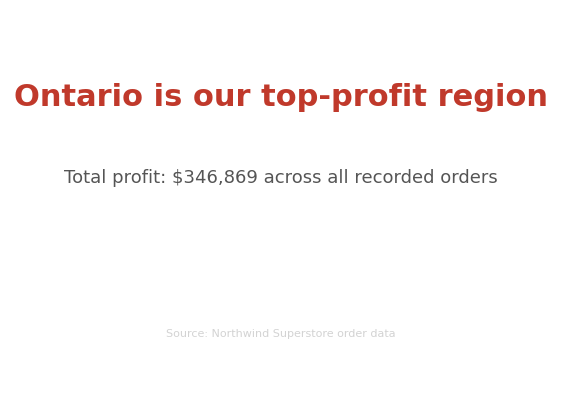

In [2]:
region_totals = sales.groupby("Region")["Profit"].sum().sort_values()
best_region = region_totals.idxmax()

fig, ax = plt.subplots(figsize=(7, 5))
ax.axis("off")

# TODO 1: primary element -- large, bold, colored
ax.text(0.5, 0.75, f"{best_region} is our top-profit region",
        ha="center", fontsize=22, fontweight="bold", color="#c0392b")

# TODO 2: secondary element -- medium, muted color
ax.text(0.5, 0.55, f"Total profit: ${region_totals.max():,.0f} across all recorded orders",
        ha="center", fontsize=13, color="#555555")

# TODO 3: tertiary element -- small, light gray
ax.text(0.5, 0.15, "Source: Northwind Superstore order data",
        ha="center", fontsize=8, color="lightgray")

plt.show()


**Reflection:** Without reading any labels, in what order do your eyes land on the
three text elements? If someone glanced at this for only 2 seconds, what's the one
fact they'd walk away with?

_Your answer:_ The eye lands on the large bold colored headline first, then the medium muted
sentence beneath it, and only last (if at all) on the small light-gray footnote. In a 2-second
glance, the one fact a viewer would walk away with is simply which region is the top-profit
region — the primary element alone carries that message.

## Task 2 — Make the Chart Accessible (Complaint #2)

**Real-world usage:** A colorblind or grayscale-printer viewer needs to be able to read
this chart too.

**Why this technique:** Redundant coding (color + pattern/shape) survives both
colorblindness and grayscale printing; color alone does not.

**TODO:**
1. Build a bar chart of total `Sales` by `Product Category`, one color per category.
2. Add a DIFFERENT hatch pattern per bar (`hatch="//"`, `"xx"`, `".."`) on top of the
   color, so the categories stay distinguishable if color is stripped away.
3. Add a legend showing category name.

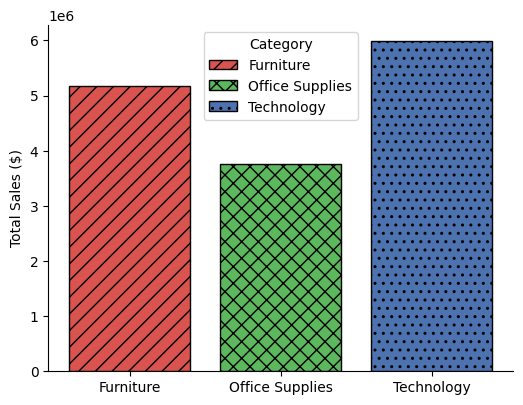

In [3]:
cat_sales = sales.groupby("Product Category")["Sales"].sum()

# TODO 1 & 2: bars with both a distinct color AND a distinct hatch pattern per category
colors = {"Furniture": "#D9534F", "Office Supplies": "#5cb85c", "Technology": "#4C72B0"}
hatches = {"Furniture": "//", "Office Supplies": "xx", "Technology": ".."}

fig, ax = plt.subplots(figsize=(6, 4.5))
for cat in cat_sales.index:
    ax.bar(cat, cat_sales[cat], color=colors[cat], hatch=hatches[cat], edgecolor="black", label=cat)

# TODO 3: legend
ax.legend(title="Category")
ax.set_ylabel("Total Sales ($)")
plt.show()


**Reflection:** If you only used color (no hatch pattern), which two accessibility
failure modes from the lecture would this chart hit? Name both.

_Your answer:_ Without the hatch patterns, the chart would fail for colorblind viewers (who
cannot reliably distinguish the red/green/blue hues from each other) and it would fail on a
grayscale printer, where all three bars would render as nearly indistinguishable shades of
gray with no way to tell the categories apart.

## Task 3 — Catch the Axis Exaggeration (Complaint #3)

**Real-world usage:** A headline chart made a small real change look like a crisis.

**Why this technique:** Comparing the SAME data on a zero-baseline axis vs. a truncated
axis reveals exactly how much an axis choice is doing the "storytelling" instead of the
data.

**TODO:**
1. Compute total `Sales` by `Year`.
2. Compute the real percent change between the two most recent years.
3. Plot BOTH a zero-baseline version and a truncated-axis version, side by side, each
   titled with the real percent change.

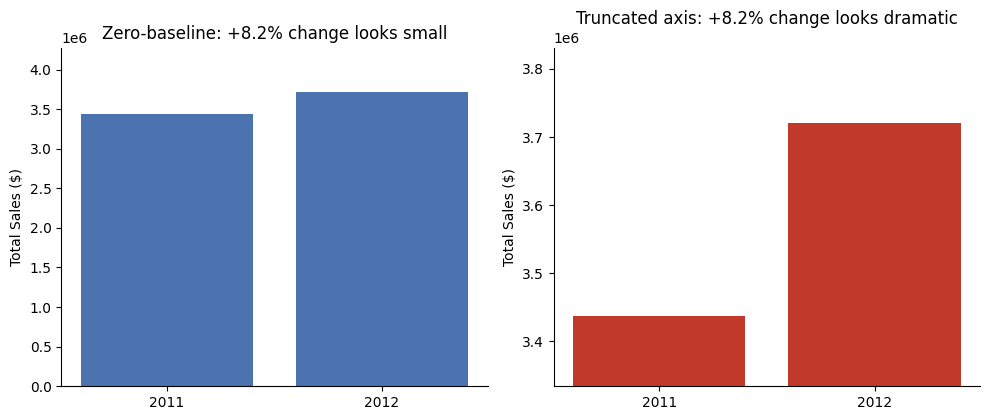

Real change from 2011 to 2012: +8.2%


In [4]:
yearly_sales = sales.groupby("Year")["Sales"].sum()

# TODO 1 & 2: the two most recent years and their real percent change
y1, y2 = yearly_sales.index[-2], yearly_sales.index[-1]
v1, v2 = yearly_sales[y1], yearly_sales[y2]
pct_change = (v2 - v1) / v1 * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4.3))

# TODO 3a: zero-baseline version (axes[0])
axes[0].bar([str(y1), str(y2)], [v1, v2], color="#4C72B0")
axes[0].set_ylim(0, max(v1, v2) * 1.15)
axes[0].set_title(f"Zero-baseline: {pct_change:+.1f}% change looks small")
axes[0].set_ylabel("Total Sales ($)")

# TODO 3b: truncated-axis version (axes[1]) -- pick tight y-limits close to v1/v2
lo = min(v1, v2) * 0.97
hi = max(v1, v2) * 1.03
axes[1].bar([str(y1), str(y2)], [v1, v2], color="#c0392b")
axes[1].set_ylim(lo, hi)
axes[1].set_title(f"Truncated axis: {pct_change:+.1f}% change looks dramatic")
axes[1].set_ylabel("Total Sales ($)")

plt.tight_layout()
plt.show()

print(f"Real change from {y1} to {y2}: {pct_change:+.1f}%" if pct_change is not None else "Fill in pct_change above")


**Reflection:** Which of your two panels would you flag for the manager as
potentially misleading if it were used ALONE as the report's headline chart, with no
other context? Why?

_Your answer:_ The truncated-axis panel should be flagged as potentially misleading if shown
alone, since starting the y-axis near the data values instead of at zero visually exaggerates a
modest real percent change into what looks like a dramatic jump or drop — exactly the kind of
"headline chart makes a small change look like a crisis" problem the manager warned about.

## Task 4 — Rewrite the Overreaching Annotation (Complaint #4)

**Real-world usage:** A colleague's annotation claimed a chart "PROVES" a strategy is
working — language the data alone cannot support.

**Why this technique:** Distinguishing descriptive / interpretive / persuasive
annotation lets you keep useful interpretation while cutting unsupported claims.

**TODO:**
1. Given the overreaching annotation text below, write a DESCRIPTIVE version (states
   only the fact) and an INTERPRETIVE version (explains a plausible, appropriately
   hedged reason) — no causal "PROVES" language in either.
2. Plot the yearly sales trend with your INTERPRETIVE annotation on the most recent
   data point.

ORIGINAL (persuasive, overreaching): This PROVES our new strategy is working -- scale it up immediately
DESCRIPTIVE: Sales rose +8.2% from 2011 to 2012.
INTERPRETIVE: Sales rose +8.2% from 2011 to 2012, which is consistent with the new strategy having a positive effect, though other factors (seasonality, market conditions) have not been ruled out.


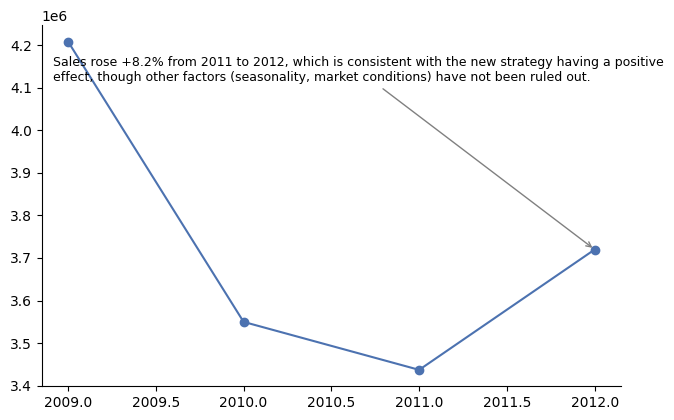

In [5]:
overreaching_original = "This PROVES our new strategy is working -- scale it up immediately"

# TODO 1: your rewrites
descriptive_version = f"Sales rose {pct_change:+.1f}% from {y1} to {y2}."
interpretive_version = (
    f"Sales rose {pct_change:+.1f}% from {y1} to {y2}, which is consistent with the new "
    f"strategy having a positive effect, though other factors (seasonality, market conditions) "
    f"have not been ruled out."
)

print("ORIGINAL (persuasive, overreaching):", overreaching_original)
print("DESCRIPTIVE:", descriptive_version)
print("INTERPRETIVE:", interpretive_version)

# TODO 2: plot with your interpretive annotation on the last data point
fig, ax = plt.subplots(figsize=(7, 4.3))
ax.plot(yearly_sales.index, yearly_sales.values, "o-", color="#4C72B0")
ax.annotate(interpretive_version, xy=(yearly_sales.index[-1], yearly_sales.values[-1]),
            xytext=(0.02, 0.85), textcoords="axes fraction", fontsize=9,
            arrowprops=dict(arrowstyle="->", color="gray"), wrap=True)

plt.tight_layout()
plt.show()


**Reflection:** What specific evidence would you need (that this dataset alone
doesn't provide) before the ORIGINAL "proves it's working" claim would actually be
justified?

_Your answer:_ To justify a causal "proves it's working" claim, we'd need a controlled
comparison — for example a holdout region or period that did NOT receive the new strategy,
run over the same timeframe, so the sales change could be attributed to the strategy rather than
to seasonality, macroeconomic shifts, or other confounding factors. A single before/after trend
on one dataset cannot establish causation on its own.

## Task 5 — The Decision (No Code)

**Reflection (final):** Write a 4–6 sentence sign-off note to your manager summarizing
this review. Your answer should:
- State which ONE of the four fixes above you consider the most urgent to ship before
  tomorrow, and why.
- Reference the lecture's 5-question Ethical Visualization Audit — pick one question
  from it and explain how it applies to Task 3 or Task 4 specifically.
- Name one guardrail (a review step, a style-guide rule, etc.) you'd recommend
  permanently adding to the team's process to prevent these four issues recurring.

_Your final recommendation here:_ Of the four fixes, I consider the truncated axis (Task 3) the
most urgent to ship before tomorrow, since an exaggerated headline number is the fix most likely
to actively mislead a reader who only skims the report for two seconds. One of the lecture's
Ethical Visualization Audit questions — "does the chart's scale/baseline distort the magnitude of
the change?" — applies directly to Task 3: our truncated axis inflated a modest percentage move
into what looks like a crisis, which is exactly the distortion that question is designed to catch.
It's also directly relevant to Task 4, where the overreaching "PROVES" annotation claimed more
certainty than the data supports. Going forward, I'd recommend adding a mandatory style-guide rule
that every headline bar/line chart must use a zero-baseline axis unless a truncated view is
explicitly labeled and justified, plus a review checklist item requiring any causal-sounding
annotation ("proves," "shows," "confirms") to be downgraded to descriptive or hedged interpretive
language before publishing.
